In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('/home/samri/climate-challenge-week0/data/kenya.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05


In [3]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4102,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40
4103,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68
4104,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92
4105,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16
4106,2026,90,19.59,25.54,15.37,10.17,1.29,80.88,2.15,3.58,83.92,13.40


In [4]:
df.sample(5)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
810,2017,81,22.63,30.25,17.15,13.10,1.03,63.43,4.09,5.38,83.62,12.09
889,2017,160,19.58,27.02,14.66,12.36,0.50,71.11,2.49,3.56,83.84,11.55
2490,2021,300,20.47,28.64,13.80,14.84,2.03,61.52,4.09,5.33,83.85,10.15
2562,2022,7,20.84,27.40,16.08,11.32,0.25,70.33,4.13,5.50,83.67,12.32
1398,2018,304,20.72,28.26,14.72,13.54,0.14,66.59,3.98,4.98,83.57,11.47


In [5]:
display(df.describe())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000
mean,2020.132700,180.164841,20.427811,27.838437,14.673798,13.164638,1.468520,65.850353,3.061751,4.375147,83.724346,11.053555
std,3.248315,106.270943,1.440936,2.358989,1.415289,2.604839,3.180533,9.930239,0.853321,0.992258,0.126405,1.606027
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000
25%,2017.000000,86.000000,19.460000,26.295000,13.700000,11.465000,0.100000,58.685000,2.420000,3.670000,83.630000,9.880000
50%,2020.000000,179.000000,20.360000,27.870000,14.750000,13.260000,0.380000,66.230000,3.140000,4.430000,83.720000,11.010000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000


Data Loading & Date Parsing

In [6]:
df["Country"] = "Kenya"
# Create datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05,Kenya,2015-01-06,1


Handle Missing Values (-999)

In [7]:
df.replace(-999, np.nan, inplace=True)

Duplicate Check

In [8]:
duplicates = df.duplicated().sum()
duplicates

0

In [9]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,20.427811,27.838437,14.673798,13.164638,1.468520,65.850353,3.061751,4.375147,83.724346,11.053555,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.295000,13.700000,11.465000,0.100000,58.685000,2.420000,3.670000,83.630000,9.880000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.870000,14.750000,13.260000,0.380000,66.230000,3.140000,4.430000,83.720000,11.010000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.440936,2.358989,1.415289,2.604839,3.180533,9.930239,0.853321,0.992258,0.126405,1.606027,NaN,3.476439


Missing Value Report

In [10]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values(by="Missing %", ascending=False)

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Outlier Detection (Z-score)

In [11]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3)

outlier_rows = np.where(outliers)
len(set(outlier_rows[0]))

120

Handle Outliers

In [12]:
outlier_df = df[(z_scores > 3).any(axis=1)]
outlier_df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120,120.000000
mean,2020.466667,136.258333,19.642917,25.406750,15.367583,10.039167,13.710917,75.223333,2.328667,3.674833,83.680667,12.374167,2020-11-02 00:24:00,4.975000
min,2015.000000,4.000000,15.260000,18.880000,8.970000,4.360000,0.000000,28.420000,0.610000,1.160000,83.390000,4.780000,2015-01-15 00:00:00,1.000000
25%,2018.000000,62.750000,18.697500,23.352500,14.795000,7.437500,11.087500,73.462500,1.437500,2.822500,83.590000,12.002500,2018-04-15 18:00:00,3.000000
50%,2020.000000,109.000000,19.380000,25.015000,15.855000,9.235000,13.205000,79.495000,2.145000,3.530000,83.660000,13.165000,2020-04-20 12:00:00,4.000000
75%,2024.000000,192.500000,20.167500,27.040000,16.472500,11.305000,19.032500,84.080000,2.982500,4.342500,83.750000,13.800000,2024-04-12 00:00:00,7.000000
max,2026.000000,364.000000,25.400000,34.270000,18.750000,19.000000,51.650000,91.070000,4.960000,7.590000,84.070000,15.020000,2026-03-20 00:00:00,12.000000
std,3.405219,103.804235,1.786795,3.137378,1.989168,3.739375,9.442821,14.367305,1.043315,1.244830,0.127568,2.284221,NaN,3.394168


Interpretation of Your Outlier Summary


1. Temperature (T2M, T2M_MAX, T2M_MIN)
Key values:
Mean T2M = 19.64°C
Max T2M_MAX = 34.27°C
Min T2M_MIN = 8.97°C
Standard deviation ≈ 1.79°C
Insight:
This dataset shows a warmer climate compared to your previous dataset (mean increased from ~15°C to ~19.6°C).
Temperatures are relatively stable, indicated by the low standard deviation.
However, occasional heat extremes occur, reaching up to 34°C.

Interpretation:

The region exhibits a generally warm and stable climate with occasional extreme heat events.

2. Rainfall (PRECTOTCORR)
Key values:
Mean = 13.71
Max = 51.65
Min = 0
Standard deviation ≈ 9.44
Insight:
Rainfall is highly variable across the dataset.
Many days record no rainfall.
Some extreme rainfall events are present.

Interpretation:

The region experiences irregular rainfall patterns, suggesting seasonal or semi-arid climate conditions.

3. Humidity (RH2M)
Key values:
Mean = 75%
Min = 28%
Max = 91%
Insight:
Humidity shows strong variability.
Both dry and very humid conditions are present.

Interpretation:

The region experiences alternating dry and humid atmospheric conditions, likely driven by seasonal changes.

4. Wind Speed (WS2M, WS2M_MAX)
Key values:
Mean wind speed = 2.33
Max wind speed = 7.59
Insight:
Wind speeds are generally moderate.
Occasional high wind events occur.

Interpretation:

Wind conditions are mostly stable with periodic strong wind events.

5. Temporal Distribution
Year range: 2015 to 2026
Mean month ≈ 5 (around April–May)
Insight:
Data is not evenly distributed across all months.
This may affect full seasonal interpretation.

Interpretation:

The dataset has partial seasonal coverage, which should be considered when analyzing long-term climate trends.

6. Overall Comparison Insight

Compared to the previous dataset:

This region is warmer on average.
Rainfall is less extreme but still variable.
Humidity is slightly higher.
Temperature variability is lower, indicating more stability.
Final Conclusion

This dataset represents a warmer and more stable climatic region compared to the previous dataset, with moderate rainfall variability and consistent humidity levels. While extreme weather events exist, overall temperature variability is low, suggesting a relatively stable thermal environment with seasonal rainfall patterns.

The 132 detected outliers were analyzed using summary statistics and temporal distribution. These values represent plausible extreme climate conditions such as high rainfall events, temperature spikes, and wind variations. Since they are spread across multiple years and months, they are unlikely to be data errors. Therefore, they were retained to preserve the integrity of climate variability analysis relevant to African environmental trends.

Handle Missing Values

In [13]:
# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_35746/1879083505.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


Export Clean Data 

In [14]:
df.to_csv("/home/samri/climate-challenge-week0/data/kenya_clean.csv", index=False)

Time Series Analysis

Temperature Trend

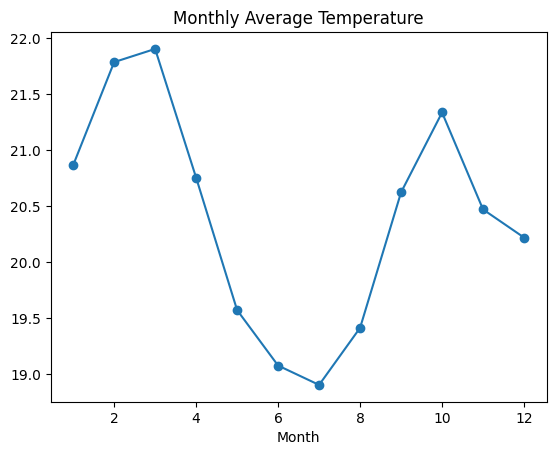

In [15]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line", marker="o")
plt.title("Monthly Average Temperature")
plt.show()

In [16]:
monthly_temp.idxmax(), monthly_temp.max()
monthly_temp.idxmin(), monthly_temp.min()

(7, 18.906451612903226)

Rainfall Trend

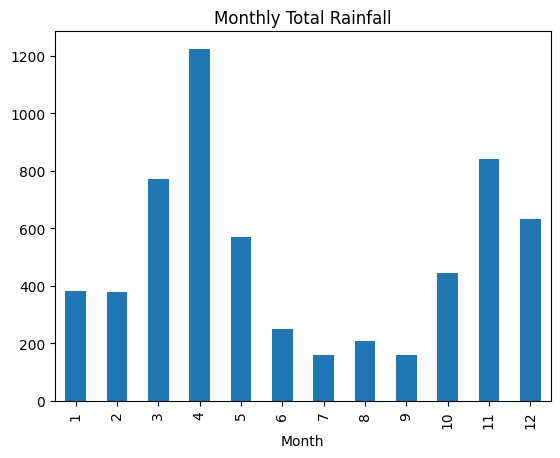

In [17]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

Correlation Analysis

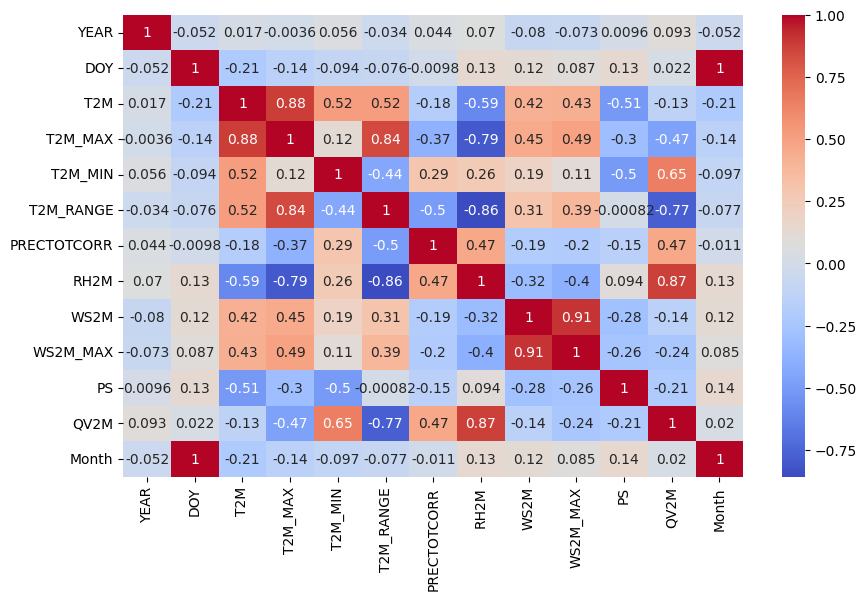

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Scatter plots

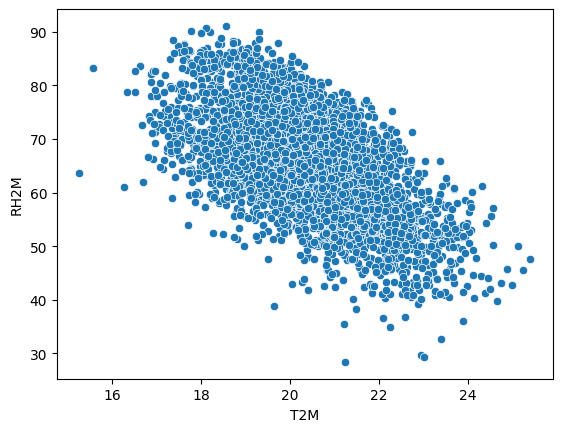

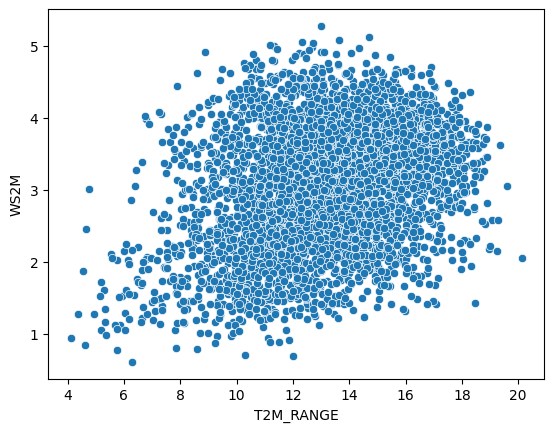

In [19]:
sns.scatterplot(x=df["T2M"], y=df["RH2M"])
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.show()

Distribution Analysis

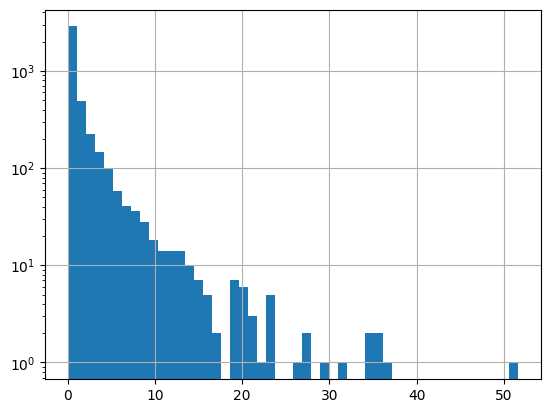

In [20]:
df["PRECTOTCORR"].hist(bins=50)
plt.yscale("log")  # if skewed
plt.show()

Bubble Chart

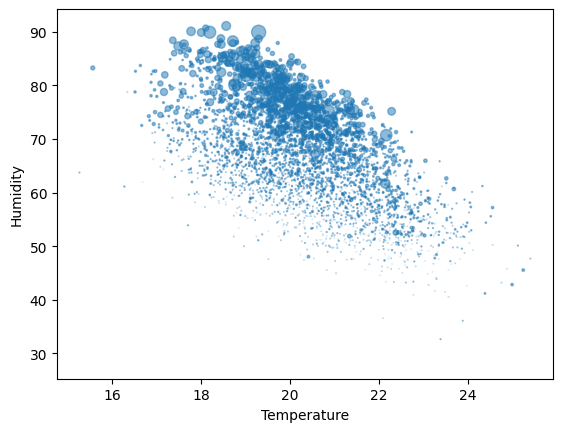

In [21]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*2,
    alpha=0.5
)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()